# Importing Libraries and loading datasets 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sales = pd.read_csv("../datasets/data warehouse/dw_fact_sales.csv")
inventory = pd.read_csv("../datasets/business datasets/data/inventory.csv")

# Inspect Data


In [2]:
sales.head()

inventory.head()

sales.columns.tolist()

inventory.columns.tolist()

['inventory_id',
 'store_id',
 'sku_id',
 'inventory_date',
 'expected_stock',
 'actual_stock',
 'stock_status']

# Merge Inventory and Sales

In [3]:
df = inventory.merge(
    sales,
    on=['store_id','sku_id'],
    how='left'
)

df.head()

,inventory_id,store_id,sku_id,inventory_date,expected_stock,actual_stock,stock_status,transaction_id,transaction_date,quantity_sold,sales_amount
0,INV000001,S001,SKU0001,2026-06-01,98,87,In Stock,T0000099,2025-10-11,7.0,206.29
1,INV000001,S001,SKU0001,2026-06-01,98,87,In Stock,T0039932,2025-04-09,4.0,117.88
2,INV000001,S001,SKU0001,2026-06-01,98,87,In Stock,T0040484,2025-05-23,10.0,294.70
3,INV000001,S001,SKU0001,2026-06-01,98,87,In Stock,T0040813,2025-12-19,7.0,206.29
4,INV000001,S001,SKU0001,2026-06-01,98,87,In Stock,T0044129,2025-02-11,3.0,88.41


In [16]:
df.columns.tolist()

['inventory_id',
 'store_id',
 'sku_id',
 'inventory_date',
 'expected_stock',
 'actual_stock',
 'stock_status',
 'transaction_id',
 'transaction_date',
 'quantity_sold',
 'sales_amount']

# Calculate Shelf Gap

In [4]:
df['stock_gap'] = (
    df['expected_stock']
    - df['actual_stock']
)

df[['expected_stock','actual_stock','stock_gap']].head()

,expected_stock,actual_stock,stock_gap
0,98,87,11
1,98,87,11
2,98,87,11
3,98,87,11
4,98,87,11


# Shelf Compliance %

In [5]:
df['shelf_compliance_pct'] = (
    df['actual_stock']
    / df['expected_stock']
)*100

df['shelf_compliance_pct'].describe()

count    100434.000000
mean         62.083881
std          27.905865
min           0.000000
25%          47.222222
50%          67.368421
75%          84.210526
max         100.000000
Name: shelf_compliance_pct, dtype: float64

# Flag Shelf Issues

In [6]:
df['shelf_issue'] = df['stock_gap'].apply(
    lambda x: "Issue" if x > 0 else "OK"
)

df['shelf_issue'].value_counts()

shelf_issue
Issue    97858
OK        2576
Name: count, dtype: int64

# Out-of-Stock SKUs

In [7]:
out_of_stock = df[
    df['actual_stock']==0
]

out_of_stock.head()

len(out_of_stock)

6711

# Number of Shelf Issues

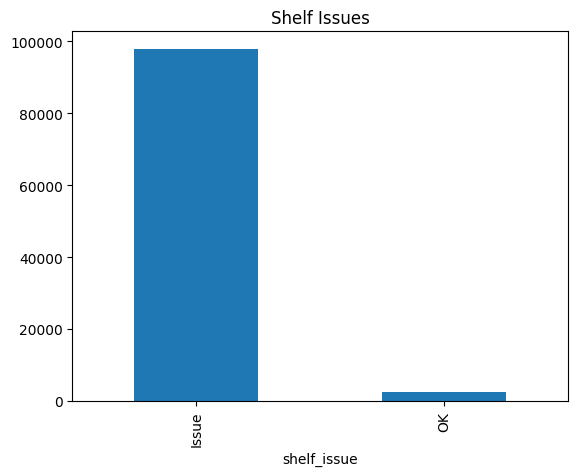

In [8]:
df['shelf_issue'].value_counts().plot(
    kind='bar'
)

plt.title("Shelf Issues")
plt.show()

# Top Stores with Maximum Shelf Gap

In [9]:
store_gap = (
    df.groupby('store_id')['stock_gap']
    .sum()
    .sort_values(ascending=False)
)

store_gap.head(10)

store_id
S003    41543
S033    41014
S032    40776
S031    40758
S049    40323
S026    40298
S021    40092
S050    40033
S017    39841
S024    39602
Name: stock_gap, dtype: int64

Plot

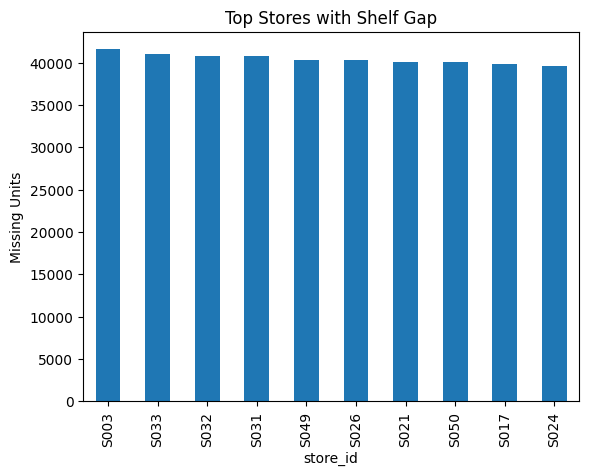

In [10]:
store_gap.head(10).plot(
    kind='bar'
)

plt.title("Top Stores with Shelf Gap")
plt.ylabel("Missing Units")
plt.show()

# Category-wise Shelf Compliance

In [13]:
sales.columns.tolist()

['transaction_id',
 'transaction_date',
 'store_id',
 'sku_id',
 'quantity_sold',
 'sales_amount']

In [14]:
df = inventory.merge(
    sales,
    on=['store_id','sku_id'],
    how='left'
)

df.columns.tolist()

['inventory_id',
 'store_id',
 'sku_id',
 'inventory_date',
 'expected_stock',
 'actual_stock',
 'stock_status',
 'transaction_id',
 'transaction_date',
 'quantity_sold',
 'sales_amount']

# Shelf Compliance %

In [17]:
df['shelf_compliance_pct'] = (
    df['actual_stock']
    / df['expected_stock']
) * 100

# Average Shelf Compliance

In [18]:
avg_compliance = df['shelf_compliance_pct'].mean()

print(
    f"Average Shelf Compliance: {avg_compliance:.2f}%"
)

Average Shelf Compliance: 62.08%


# Stock Gap

In [19]:
df['stock_gap'] = (
    df['expected_stock']
    - df['actual_stock']
)

# Worst SKUs

In [20]:
worst_skus = (
    df.groupby('sku_id')['stock_gap']
    .mean()
    .sort_values(ascending=False)
)

worst_skus.head(10)

sku_id
SKU0160    23.990566
SKU0159    23.756345
SKU0036    23.416268
SKU0103    23.112108
SKU0182    22.822660
SKU0289    22.818653
SKU0239    22.771144
SKU0345    22.664740
SKU0134    22.599057
SKU0072    22.555000
Name: stock_gap, dtype: float64

# Stock Status Count

In [21]:
df['stock_status'].value_counts()

stock_status
In Stock        89083
Out of Stock     6711
Low Stock        4640
Name: count, dtype: int64

# Pie Chart

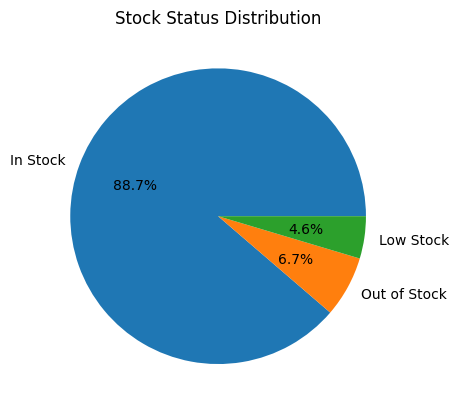

In [22]:
df['stock_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Stock Status Distribution')
plt.show()

# Expected vs Actual Stock 

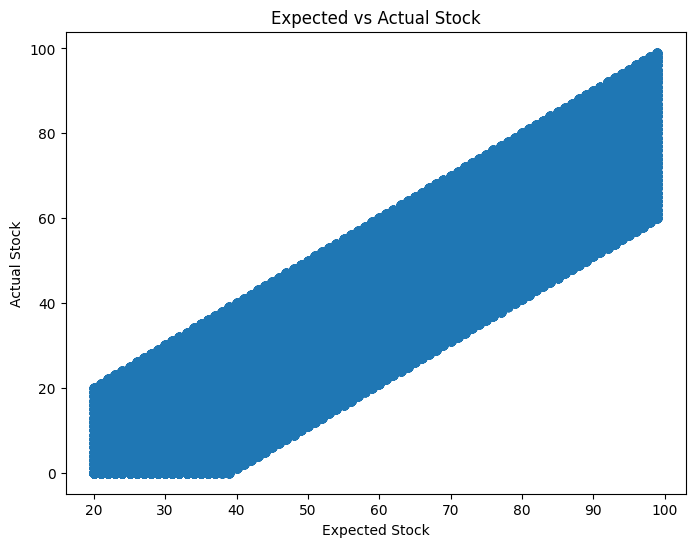

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['expected_stock'],
    df['actual_stock']
)

plt.xlabel('Expected Stock')
plt.ylabel('Actual Stock')
plt.title('Expected vs Actual Stock')

plt.show()

# Top 10 Missing Inventory SKUs

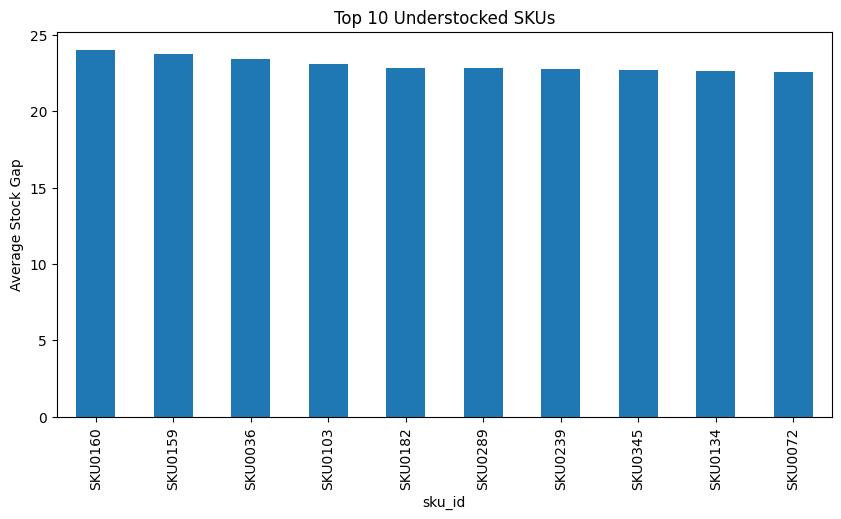

In [24]:
top_gap = (
    df.groupby('sku_id')['stock_gap']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_gap.plot(kind='bar')

plt.ylabel('Average Stock Gap')
plt.title('Top 10 Understocked SKUs')

plt.show()

# Relation between Sales and Stock

In [25]:
sales_stock = (
    df.groupby('sku_id')
    .agg({
        'quantity_sold':'sum',
        'actual_stock':'mean'
    })
)

sales_stock.head()

,quantity_sold,actual_stock
sku_id,,
SKU0001,1028.0,40.638298
SKU0002,1049.0,40.591160
SKU0003,1225.0,42.414286
SKU0004,1153.0,46.248848
SKU0005,1099.0,38.635000


# Scatter Plot

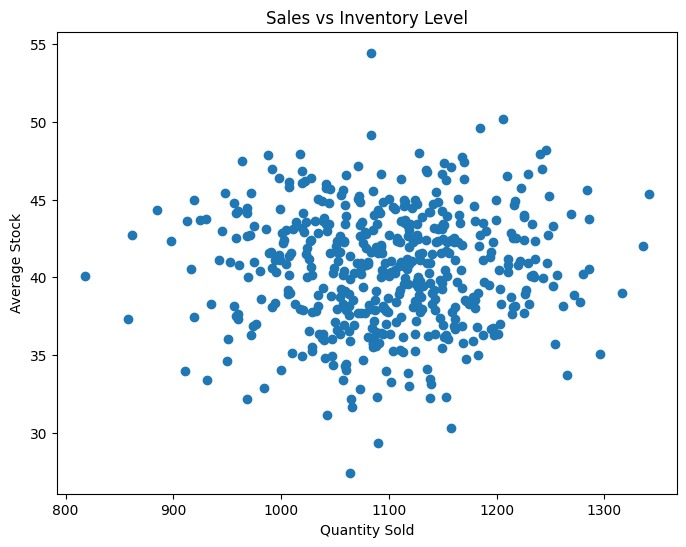

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    sales_stock['quantity_sold'],
    sales_stock['actual_stock']
)

plt.xlabel('Quantity Sold')
plt.ylabel('Average Stock')

plt.title(
    'Sales vs Inventory Level'
)

plt.show()

# High Sales + Low Inventory Products

In [27]:
critical_products = sales_stock[
    (sales_stock['quantity_sold'] >
     sales_stock['quantity_sold'].median())
    &
    (sales_stock['actual_stock'] <
     sales_stock['actual_stock'].median())
]

critical_products.head(20)

,quantity_sold,actual_stock
sku_id,,
SKU0006,1154.0,40.074627
SKU0022,1110.0,39.184080
SKU0024,1127.0,40.028846
SKU0026,1172.0,38.443902
SKU0027,1140.0,38.981395
SKU0034,1254.0,35.687500
SKU0035,1168.0,39.311881
SKU0036,1197.0,36.722488
SKU0037,1106.0,40.497462


# Save Final Dataset

In [28]:
df.to_csv(
    "../datasets/processed datasets/shelf_intelligence_analysis.csv",
    index=False
)